# Real Estate Price Prediction
This project predicts real estate prices using a dataset of 414 property transactions from Taiwan. The workflow follows a standard regression pipeline: exploratory data analysis, correlation analysis, feature selection, and model comparison. The approach is based on a reference solution (thecleverprogrammer.com / amanxai.com), reviewed prior to building an independent implementation. Unlike the reference, this notebook compares multiple regression models and reports standard evaluation metrics (R2, MAE, RMSE).

Dataset: Real_Estate.csv, 414 rows and 7 columns (transaction date, house age, distance to nearest MRT station, number of nearby convenience stores, latitude, longitude, house price per unit area).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/Regression/real_estate_price_prediction')


In [4]:
df = pd.read_csv("Real_Estate.csv")

In [5]:
df.head()

,Transaction date,House age,Distance to the nearest MRT station,Number of convenience stores,Latitude,Longitude,House price of unit area
0,2012-09-02 16:42:30.519336,13.3,4082.0150,8,25.007059,121.561694,6.488673
1,2012-09-04 22:52:29.919544,35.5,274.0144,2,25.012148,121.546990,24.970725
2,2012-09-05 01:10:52.349449,1.1,1978.6710,10,25.003850,121.528336,26.694267
3,2012-09-05 13:26:01.189083,22.2,1055.0670,5,24.962887,121.482178,38.091638
4,2012-09-06 08:29:47.910523,8.5,967.4000,6,25.011037,121.479946,21.654710


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 7 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Transaction date                     414 non-null    str    
 1   House age                            414 non-null    float64
 2   Distance to the nearest MRT station  414 non-null    float64
 3   Number of convenience stores         414 non-null    int64  
 4   Latitude                             414 non-null    float64
 5   Longitude                            414 non-null    float64
 6   House price of unit area             414 non-null    float64
dtypes: float64(5), int64(1), str(1)
memory usage: 33.3 KB


In [7]:
df.isnull().sum()

Transaction date                       0
House age                              0
Distance to the nearest MRT station    0
Number of convenience stores           0
Latitude                               0
Longitude                              0
House price of unit area               0
dtype: int64

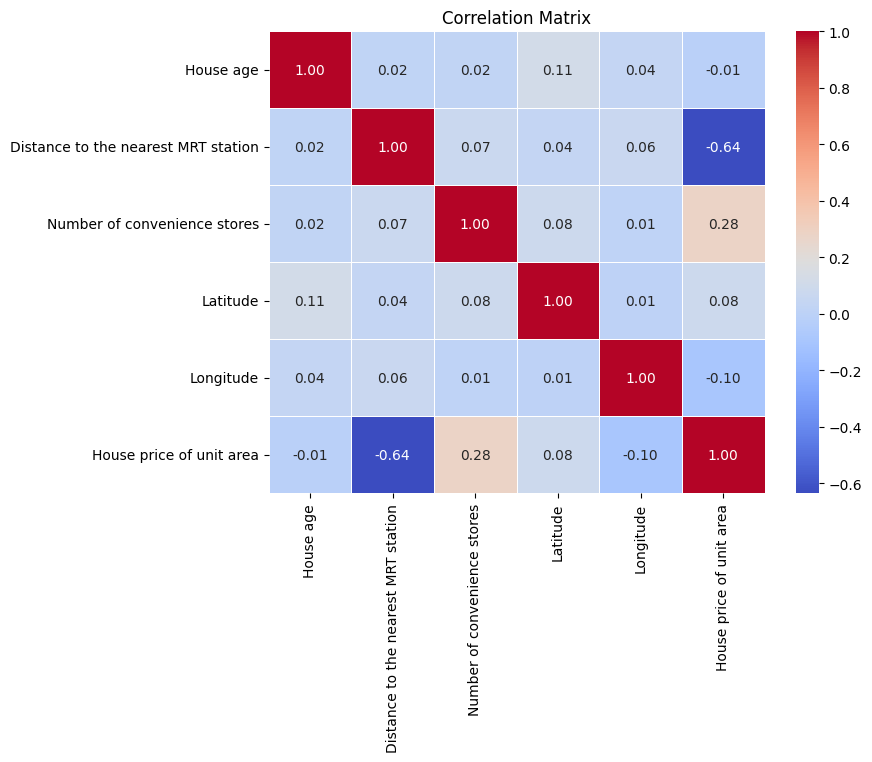

In [8]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

### Golden Rule
0.20 < |r| < 0.90

In [9]:
candidate_features = [
    "House age",
    "Distance to the nearest MRT station",
    "Number of convenience stores",
    "Latitude",
    "Longitude",
]

correlation_report = []
for feature in candidate_features:
    r, p = pearsonr(df[feature], df["House price of unit area"])
    correlation_report.append({"Feature": feature, "r": r, "p_value": p})

correlation_report_df = pd.DataFrame(correlation_report).set_index("Feature")
correlation_report_df

,r,p_value
Feature,,
House age,-0.012284,8.032075e-01
Distance to the nearest MRT station,-0.636579,2.014902e-48
Number of convenience stores,0.280763,6.145743e-09
Latitude,0.081008,9.976678e-02
Longitude,-0.098626,4.490239e-02


In [13]:
features = ["Distance to the nearest MRT station", "Number of convenience stores"]
target = "House price of unit area"

x = df[features]
y = df[target]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

x_train.shape, x_test.shape

((331, 2), (83, 2))

In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

results = []

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({"Model": name, "R2": r2, "MAE": mae, "RMSE": rmse})

results_df = pd.DataFrame(results).set_index("Model")
results_df

,R2,MAE,RMSE
Model,,,
Linear Regression,0.553879,9.730508,11.109268
Ridge Regression,0.553895,9.730201,11.109066
Random Forest,0.414248,10.276385,12.729641
Gradient Boosting,0.480777,10.124605,11.984941


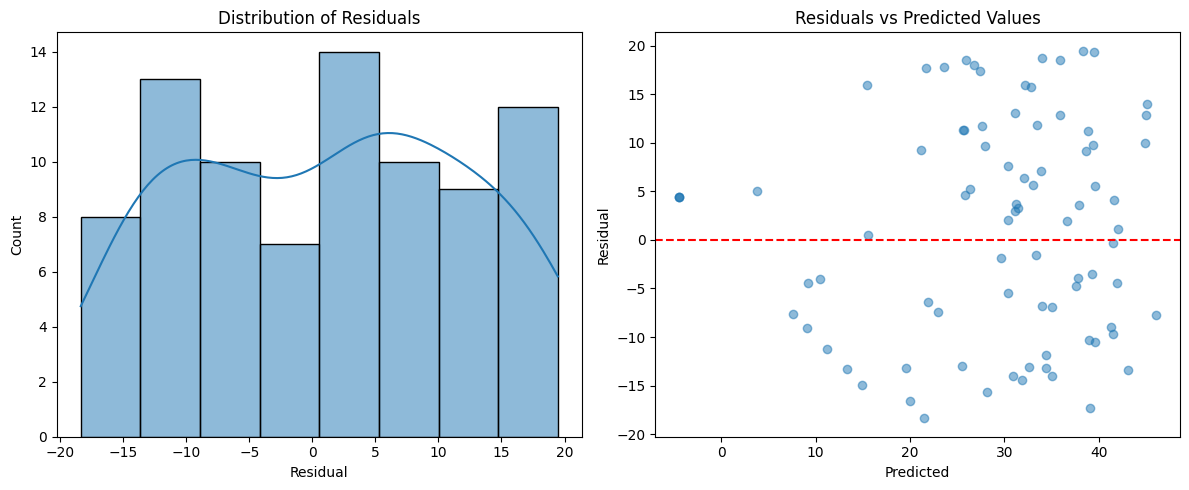

In [15]:
best_model = Ridge()
best_model.fit(x_train, y_train)
y_pred = best_model.predict(x_test)

residuals = y_test - y_pred

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")

plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color="r", linestyle="--")
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()

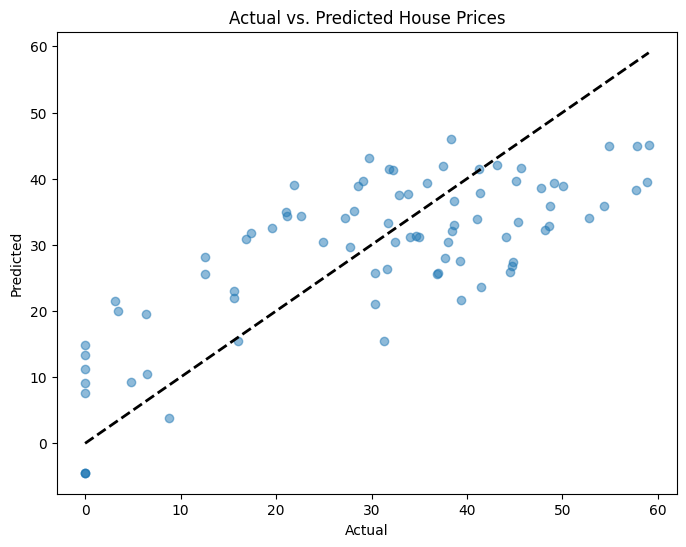

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs. Predicted House Prices")
plt.show()

### Sonuç
Ridge Regression, istatistiksel özellik seçimi sonrasında (sadece Distance to the nearest MRT station ve Number of convenience stores'un hem p-value hem golden rule kriterlerini geçmesiyle) final model olarak seçildi. Test setinde R²=0.554, MAE=9.73, RMSE=11.11 elde edildi - bu, hem Random Forest hem Gradient Boosting'den daha iyi bir sonuç, çünkü bu ağaç tabanlı modeller küçük veri setinde (331 satırlık train, sadece 2 özellik) muhtemelen overfitting'e yatkın davrandı.

R²>0.85 hedefine göre bu sonuç yetersiz kaldı. Actual-vs-predicted grafiği, gerçek fiyatı sıfıra yakın olan birkaç mülkte modelin sistematik olarak yüksek tahmin yaptığını gösterdi - bunlar muhtemelen aykırı değer/veri hatası, temsili düşük fiyatlı mülkler değil. Residuals dağılımı simetrik ama tam normal değil, iki tepeli bir yapı gösterdi - bu, sadece iki özellikle yakalanamayan sistematik bir varyasyon kaynağının var olduğuna işaret ediyor. Olumlu tarafta, residuals-vs-predicted grafiğinde huni şekli yok, yani hatanın büyüklüğü tahmin edilen fiyatla birlikte büyümüyor.

Genel olarak, elde tutulan iki özellik (toplu taşımaya yakınlık ve çevre olanakları) gerçek ama kısmi bir sinyal taşıyor. Daha yüksek bir R²'ye ulaşmak muhtemelen bu veri setinde bulunmayan ek mülk-düzeyi özellikler (metrekare, oda sayısı, bina durumu gibi) gerektirirdi. Referans çözümle karşılaştırıldığında, bu analiz istatistiksel özellik seçimini, dört modelli karşılaştırmayı ve residual analizini eklemiş oldu - hiçbiri orijinal makalede yoktu.